In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Bina kisi lambe path ke, sirf asli naam aur space ka dhyan rakhte通
df = pd.read_csv('E-commerce Dataset.csv', encoding='ISO-8859-1')

df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


In [74]:
# 1. Check karte hain dataset ka shape (rows, columns)
print("Dataset ka size:", df.shape)

# 2. Columns ki poori jankari aur missing values check karte hain
df.info()

Dataset ka size: (51290, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment

In [75]:
# 1. Check karte hain kis column mein kitni khali (Missing) jagah hai
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Check karte hain sales, quantity aur profit ka hisab-kitab (Summary Statistics)
print("\n--- Numerical Columns Ka Summary ---")
df[['Sales', 'Quantity', 'Profit', 'Discount']].describe()

--- Missing Values ---
Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

--- Numerical Columns Ka Summary ---


,Sales,Quantity,Profit,Discount
count,51289.000000,51288.000000,51290.000000,51289.000000
mean,152.340872,2.502983,70.407226,0.303821
std,66.495419,1.511859,48.729488,0.131027
min,33.000000,1.000000,0.500000,0.100000
25%,85.000000,1.000000,24.900000,0.200000
50%,133.000000,2.000000,59.900000,0.300000
75%,218.000000,4.000000,118.400000,0.400000
max,250.000000,5.000000,167.500000,0.500000


In [76]:
# 1. Missing Customer_Id ko 'Unknown' se fill karte hain
df['Customer_Id'] = df['Customer_Id'].fillna('Unknown')

# 2. Ek naya column bana rahe hain 'Order_Status'
# Agar Quantity 0 se kam (< 0) hai toh 'Cancelled', nahi toh 'Completed'
df['Order_Status'] = np.where(df['Quantity'] < 0, 'Cancelled', 'Completed')

# 3. Chaliye check karte hain ki kul kitne orders cancel hue aur kitne sahi hain
print(df['Order_Status'].value_counts())

Order_Status
Completed    51290
Name: count, dtype: int64


In [77]:
# 1. Order_Date ko sahi datetime format mein convert karte hain
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. Date mein se Month ka naam alag nikalte hain (January, February...)
df['Month'] = df['Order_Date'].dt.strftime('%B')

# 3. Date mein se Day ka naam alag nikalte hain (Monday, Tuesday...)
df['Day_of_Week'] = df['Order_Date'].dt.strftime('%A')

# 4. Time column mein se sirf 'Hour' (ghanta) alag nikalte hain analytics ke liye
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Chaliye dekhte hain hamare naye columns kaise jud gaye hain
df[['Order_Date', 'Month', 'Day_of_Week', 'Hour']].head()

,Order_Date,Month,Day_of_Week,Hour
0,2018-01-02,January,Tuesday,10
1,2018-07-24,July,Tuesday,20
2,2018-11-08,November,Thursday,8
3,2018-04-18,April,Wednesday,19
4,2018-08-13,August,Monday,21


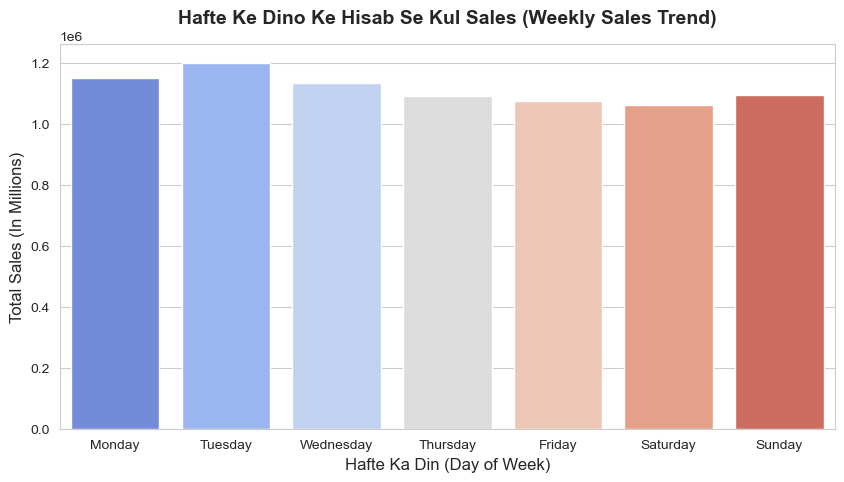

In [78]:
# 1. Hafte ke dino ke hisab se data ko group karke kul sales nikalte hain (Sirf Completed orders ki)
completed_orders = df[df['Order_Status'] == 'Completed']
weekly_sales = completed_orders.groupby('Day_of_Week')['Sales'].sum().reset_index()

# 2. Days ko sahi order mein set karte hain (Monday se Sunday)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales['Day_of_Week'] = pd.Categorical(weekly_sales['Day_of_Week'], categories=days_order, ordered=True)
weekly_sales = weekly_sales.sort_values('Day_of_Week')

# 3. Graph ka size aur style set karte hain
plt.figure(figsize=(10, 5))
sns.set_style('whitegrid')

# 4. Seaborn se Barplot banate hain (Humne 'coolwarm' color palette use ki hai)
sns.barplot(x='Day_of_Week', y='Sales', data=weekly_sales, palette='coolwarm')

# 5. Graph ke labels aur title set karte hain
plt.title('Hafte Ke Dino Ke Hisab Se Kul Sales (Weekly Sales Trend)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hafte Ka Din (Day of Week)', fontsize=12)
plt.ylabel('Total Sales (In Millions)', fontsize=12)

# Graph ko display karte hain
plt.show()

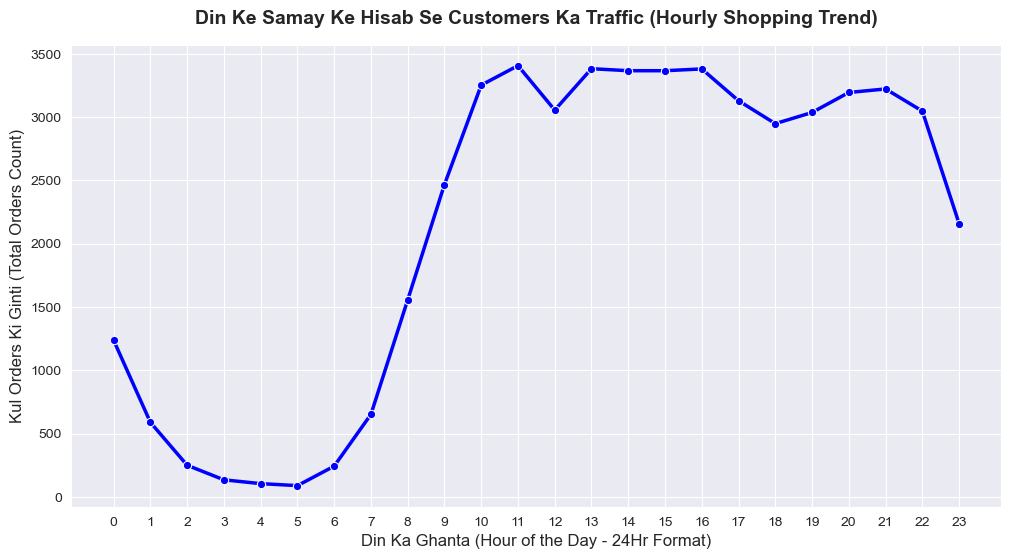

In [79]:
# 1. Hours ke hisab se 'Sales' ka count nikalte hain (Traffic check karne ke liye)
hourly_traffic = completed_orders.groupby('Hour')['Sales'].count().reset_index()

# 2. Graph ka size aur style set karte hain
plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')

# 3. Seaborn se Lineplot banate hain (Sales count ko y-axis par rakha hai)
sns.lineplot(x='Hour', y='Sales', data=hourly_traffic, marker='o', color='b', linewidth=2.5)

# 4. X-axis par saare 24 ghante sahi se dikhane ke liye ticks set karte hain
plt.xticks(range(0, 24))

# 5. Labels aur Title lagate hain
plt.title('Din Ke Samay Ke Hisab Se Customers Ka Traffic (Hourly Shopping Trend)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Din Ka Ghanta (Hour of the Day - 24Hr Format)', fontsize=12)
plt.ylabel('Kul Orders Ki Ginti (Total Orders Count)', fontsize=12)

# Graph ko display karte hain
plt.show()

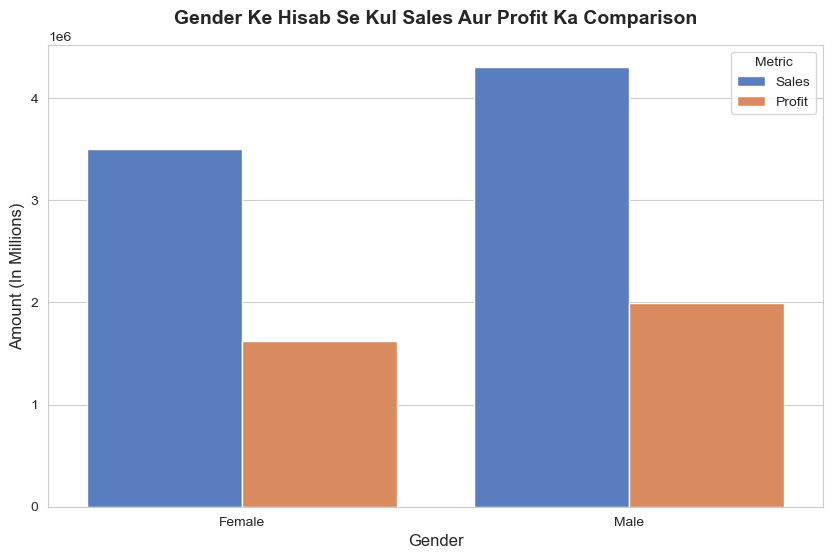

In [80]:
# 1. Gender ke hisab se Sales aur Profit ka total nikalte hain
gender_analytics = completed_orders.groupby('Gender')[['Sales', 'Profit']].sum().reset_index()

# 2. Data ko 'melt' karte hain taaki ek hi graph mein Sales aur Profit dono dikha sakein
gender_melted = pd.melt(gender_analytics, id_vars='Gender', var_name='Metric', value_name='Amount')

# 3. Graph ka size aur style set karte hain
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

# 4. Seaborn se Grouped Bar Chart banate hain
sns.barplot(x='Gender', y='Amount', hue='Metric', data=gender_melted, palette='muted')

# 5. Labels aur Title lagate hain
plt.title('Gender Ke Hisab Se Kul Sales Aur Profit Ka Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Amount (In Millions)', fontsize=12)

# Graph ko display karte hain
plt.show()

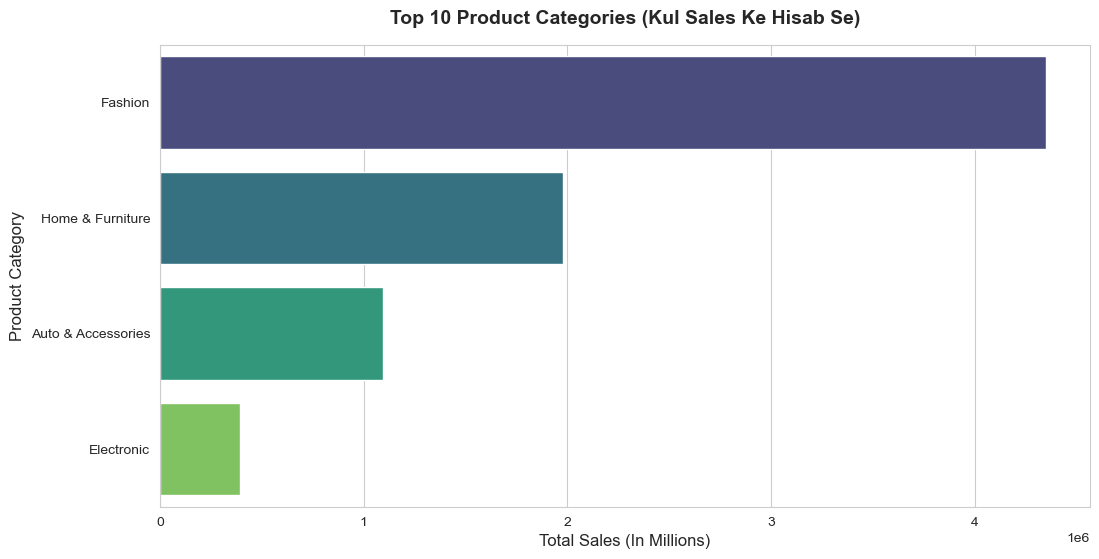

In [81]:
# 1. Product Category ke hisab se kul sales nikalte hain aur top 10 ko select karte hain
top_categories = completed_orders.groupby('Product_Category')['Sales'].sum().reset_index()
top_categories = top_categories.sort_values(by='Sales', ascending=False).head(10)

# 2. Graph ka size aur style set karte hain
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# 3. Horizontal Bar Plot banate hain (x aur y ko swap kar diya hai)
sns.barplot(x='Sales', y='Product_Category', data=top_categories, palette='viridis')

# 4. Labels aur Title lagate hain
plt.title('Top 10 Product Categories (Kul Sales Ke Hisab Se)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales (In Millions)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Graph ko display karte hain
plt.show()